Importing the necessary libraries

In [145]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rc

Loading the data set we will use in trainig the model

In [146]:
df = pd.read_csv('train.csv', index_col=0)
df.head(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


Looking for information on the data set, including columns and its data type using df.info(),the statistical analysis of the data using df.describe() and the shape of the dataset

In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

In [148]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [149]:
df.shape

(1460, 80)

**Data Exploration and Cleaning**

1.We start by dropping dropping columns thaht are will have zero to no impact to our model
PoolQC, Fence, MiscFeature, Alley 

In [150]:
#syntax
#df = df.drop(columns=['column_nameA', 'column_nameB'])

df = df.drop(columns=['PoolQC', 'Fence', 'MiscFeature', 'Alley'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemodAdd 

**2.Fiiling with none, for columns thta do not have specific features: GarageType, GarageFinish, GarageQual, GarageCond
FireplaceQu, BsmtFinType2, BsmtFinType1, BsmtCond, BsmtExposure, BsmtQual**

In [151]:
#synax
#df[['A', 'B']] = df[['A', 'B']].fillna(value=None)

df[['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond' ,'FireplaceQu', 'BsmtFinType2','BsmtFinType1','BsmtCond','BsmtExposure','BsmtQual', 'MasVnrType', 'Electrical']] = df[['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond' ,'FireplaceQu', 'BsmtFinType2','BsmtFinType1','BsmtCond','BsmtExposure','BsmtQual', 'MasVnrType', 'Electrical']].fillna('None')
df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemodAdd 

3.Filling zero for numerical colums: GarageYrBlt, MasVnrArea

In [152]:
df[['GarageYrBlt', 'MasVnrArea']] = df[['GarageYrBlt', 'MasVnrArea']].fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemodAdd 

4.Filling the LotFrontage with median because it may affect the skewness of the data model

In [153]:
df['LotFrontage']= df['LotFrontage'].fillna(df['LotFrontage'].median())
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 76 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   LotShape       1460 non-null   object 
 6   LandContour    1460 non-null   object 
 7   Utilities      1460 non-null   object 
 8   LotConfig      1460 non-null   object 
 9   LandSlope      1460 non-null   object 
 10  Neighborhood   1460 non-null   object 
 11  Condition1     1460 non-null   object 
 12  Condition2     1460 non-null   object 
 13  BldgType       1460 non-null   object 
 14  HouseStyle     1460 non-null   object 
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemodAdd 

<b>Visualizing the data to get a little bit more context on the data<b>

**1. Bar Graph**

We are plotting the house sales over the years, to observe the trend over the years.
We first create a new data fram with the variables we are concerned with, years and sales, rename the columns, and then visualize it

In [154]:
df1 = df[['SalePrice', 'YrSold']]
df1.head(5)

,SalePrice,YrSold
Id,,
1,208500,2008
2,181500,2007
3,223500,2008
4,140000,2006
5,250000,2008


In [155]:
#definig the x axis and y axis
y_axis = df1['SalePrice']
x_axis = df1['YrSold']

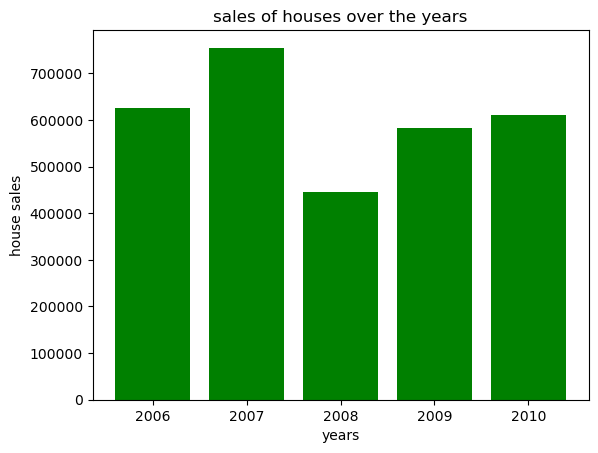

In [156]:
#plotting a simple bar graph to show the sales over the years
#a line graph would be more appropriate but it is fucking with me

plt.bar(x_axis, y_axis, color='green')
plt.title('sales of houses over the years')
plt.xlabel('years')
plt.ylabel('house sales')
plt.show()

**Bar Chart Interpretation**
The sell of houses peaked in 2007. There was a decline in 2008, which could be because of ecnomical factors. In 2009, there was a recovery from the previous year and a steady increase all to 2010.

**2. Scatter Plot**

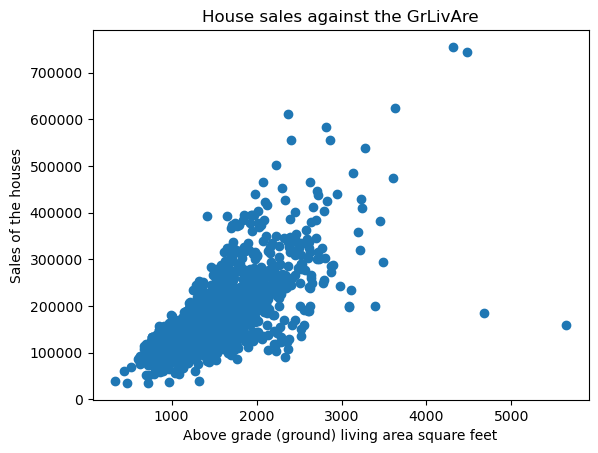

In [157]:
#Plotting the sales against the GrLivAre
plt.scatter(df['GrLivArea'], df['SalePrice'])
plt.title('House sales against the GrLivAre')
plt.ylabel('Sales of the houses')
plt.xlabel('Above grade (ground) living area square feet')
plt.show()

**ScATTER PLOT INTERPRETEATION**
1. Strong correation
-Area that have a larger space(4000 to 5000) sqaure feet tend to cost more(400,000 and above)/ have higher prices
2.Presence of ouliers
-Some houses with larger spaces of  more than 4000 square feet were sold for less than 300,000
3.Clustering
-Most houses cluster between 1000 and 3000 square feet 

**3. BOX PLOT**

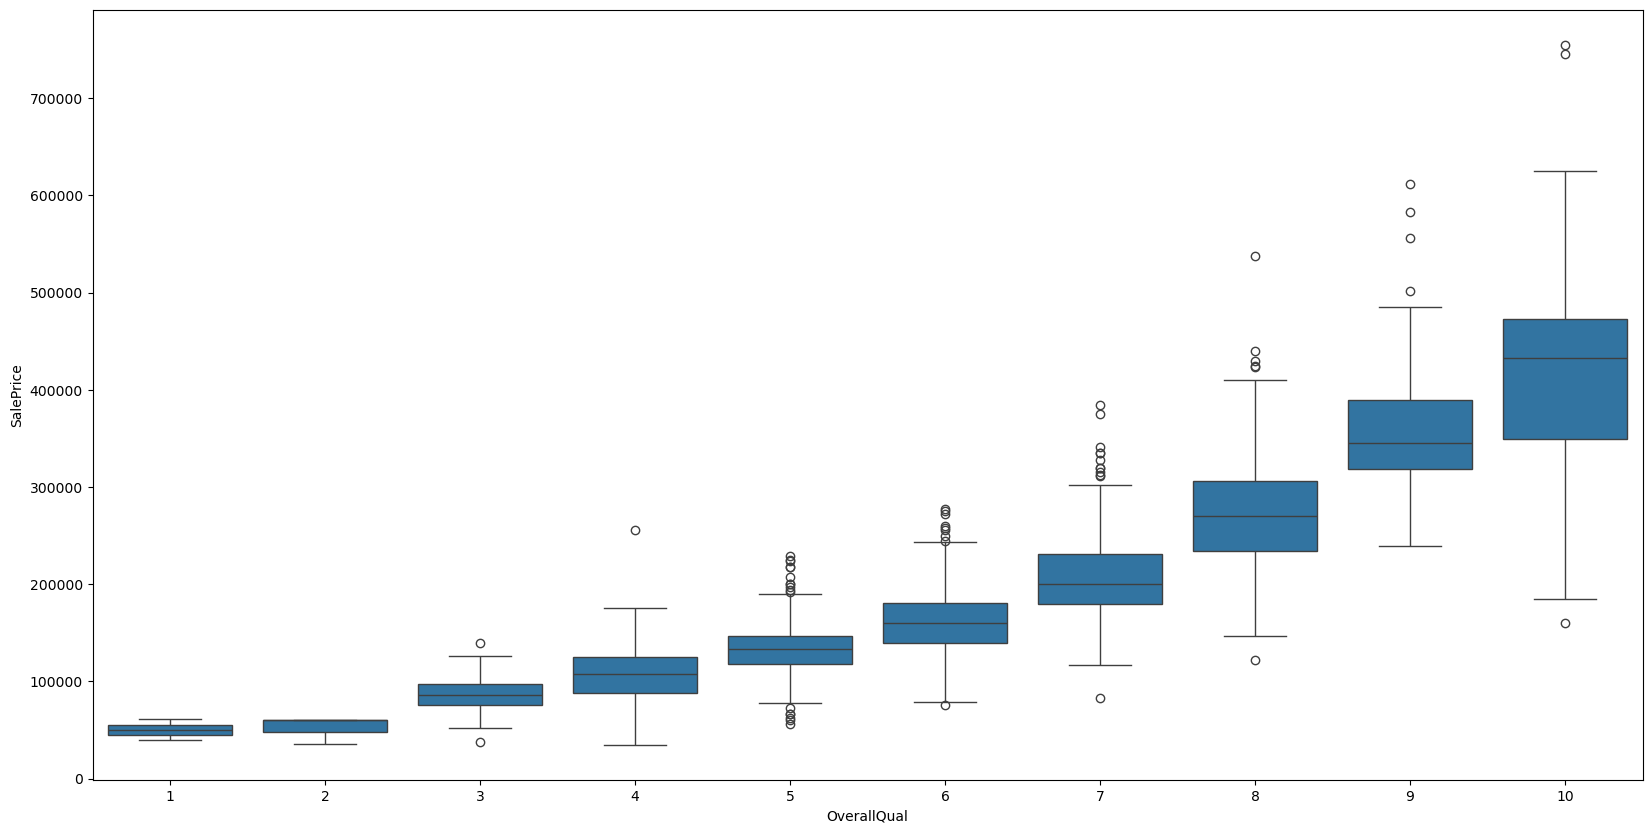

In [164]:
df2 = df[['SalePrice', 'OverallQual']]
#df2.head(5)

plt.figure(figsize=(20, 10))
sns.boxplot(data=df2, x='OverallQual', y='SalePrice', )
plt.show()

**Box plot interpreation**

Quality 1 - 4
very tight boxes, low prices, low variatons. low quality houses are consistently cheap

Quality 5 - 6
boxes are wider, thus meaning there is variation in prices, due to variation of quality

Quality 7 - 10
boxes get taller. Higher quality houses have a varying selling price

Realtionship
OverallQaul has a near linear relationship with prices. Higher quality equates higher prices

Outliers
These includes the circles above the box. The most expensive house being the one above quality 10

**Box Plot**

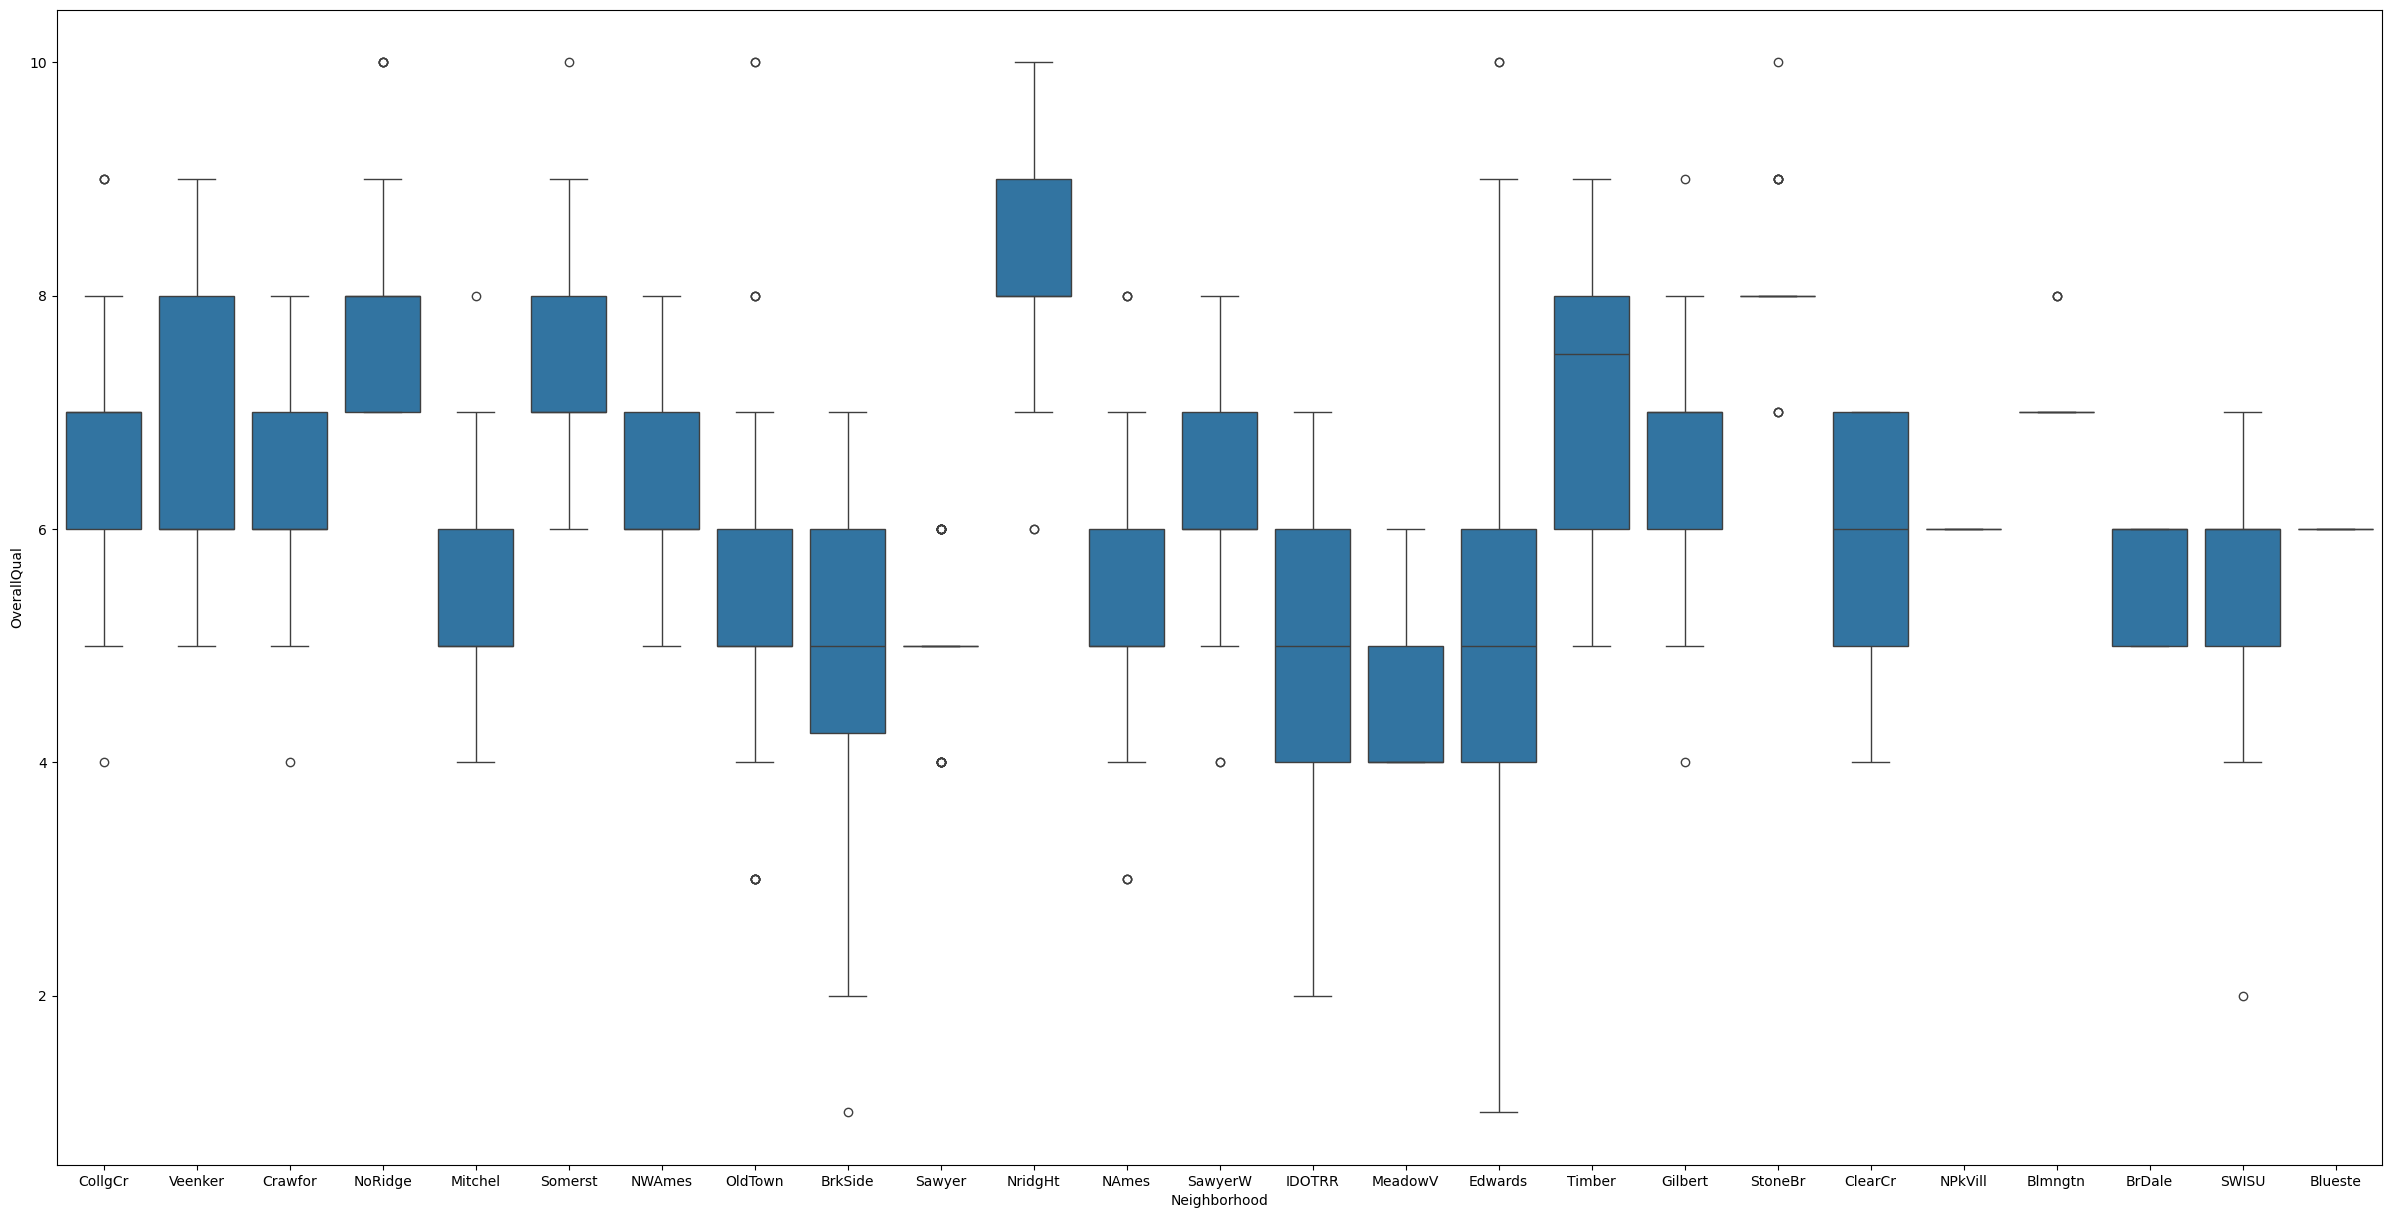

In [171]:
df3 = df[['OverallQual', 'Neighborhood']]

plt.figure(figsize=(30, 15))
sns.boxplot(data=df3, y='OverallQual', x='Neighborhood')
plt.show()

**Heat Map**

**Scatter Plot**

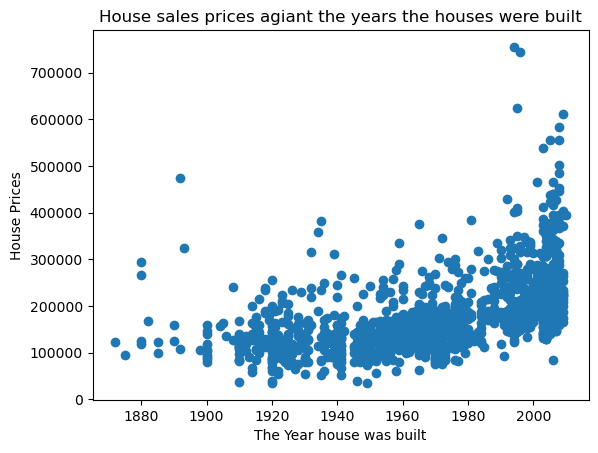

In [175]:
plt.scatter(df['YearBuilt'], df['SalePrice'], )
plt.title('House sales prices agiant the years the houses were built')
plt.xlabel('The Year house was built')
plt.ylabel('House Prices')
plt.show()

**Box Plot**

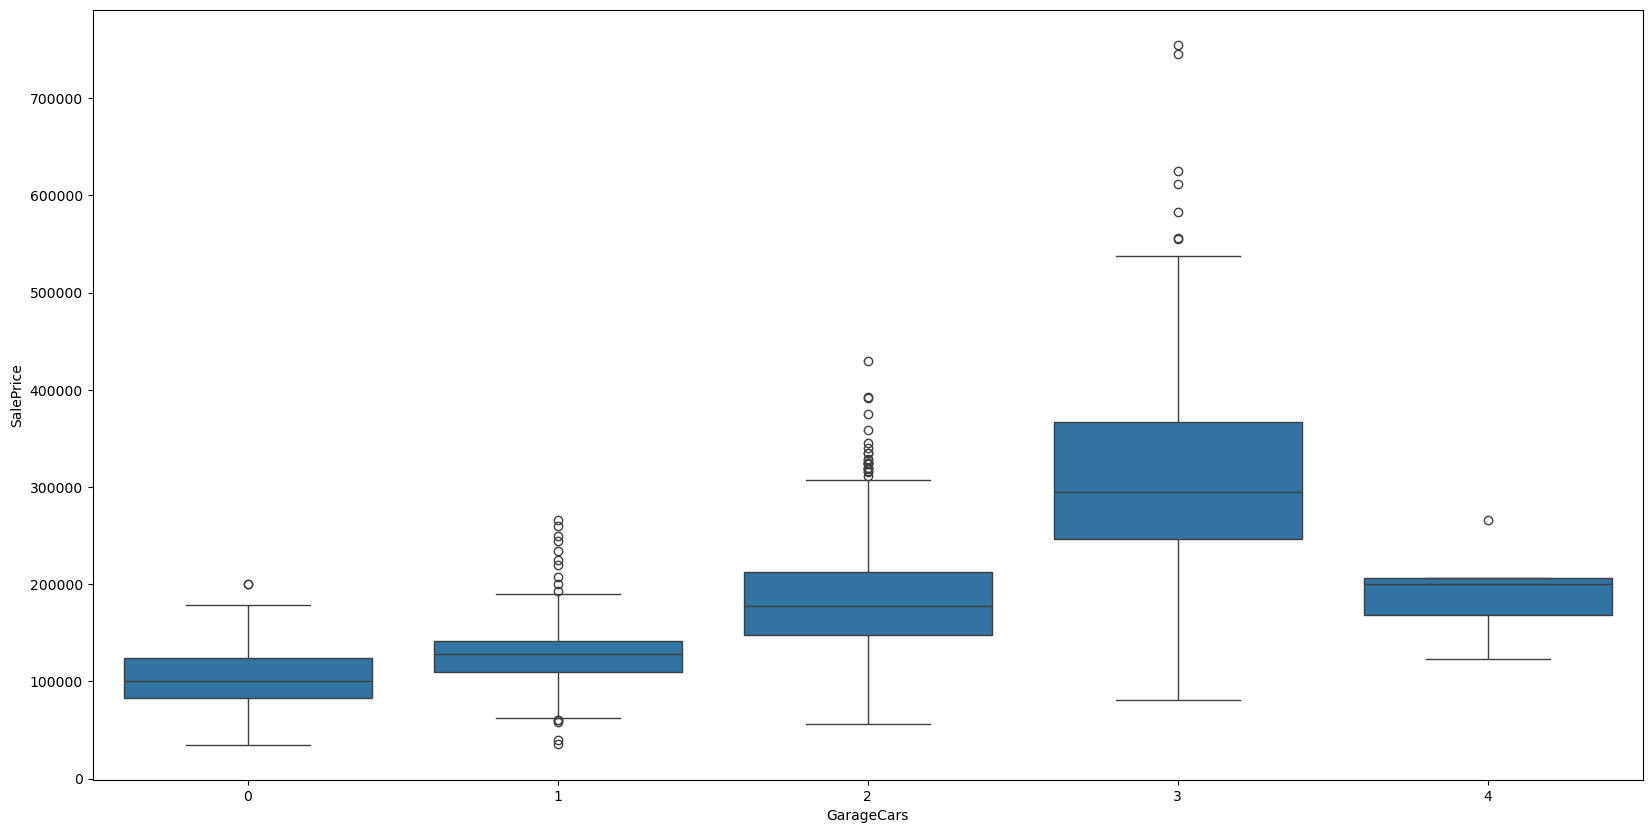

In [172]:
df4 = df[['GarageCars','SalePrice']]

plt.figure(figsize=(20, 10))
sns.boxplot(data=df4, x='GarageCars', y='SalePrice')
plt.show()